### Importando as bibliotecas

In [211]:
import pandas as pd # Trabalha com as tabelas de dados
import numpy as np # Operações matemáticas e arrays
import seaborn as sns # Criação de gráficos estatisticos mais bonitos
import matplotlib.pyplot as plt # Criação de gráficos
import warnings
warnings.filterwarnings('ignore') # Remove as mensagens de aviso desnecessários

# Scikit Learn: A nossa biblioteca principal 
from sklearn.ensemble import RandomForestClassifier # Nosso modelo será randon forest
from sklearn.metrics import RocCurveDisplay
from sklearn.linear_model import LogisticRegression # Modelo em Ressão Logistica
from sklearn.neighbors import KNeighborsClassifier # Modelo em Vizinhos próximos
from sklearn.model_selection import cross_val_score # Validação cruzada
from sklearn.metrics import (
  accuracy_score, # % de acertos
  classification_report, # Relatório completo de métricas
  confusion_matrix, # Tabela de acertos e erros
  roc_auc_score, # Qualidade geral do modelo (0.5= aleatório, 1= perfeito)
  roc_curve # Curva ROC para visualização
)

### Configurando o estilo dos gráficos

In [212]:
# Configuração de estilo dos gráficos

plt.style.use('seaborn-v0_8-pastel') # tons de pastel do matplotlib
sns.set_palette('pastel') # tons de pastel do seaborn

## Carregamento

### Baixando dados do Ibovespa (Últimos dois anos (2024-2026))

In [213]:
# Últimos 2 anos de dados diários
df = pd.read_csv('./dados/ibovespa.csv')

# Visualizando as primeiras 5 linhas do dataset

df.head()

,Data,Último,Abertura,Máxima,Mínima,Vol.,Var%
0,27.02.2026,188.787,191.005,191.005,188.478,"11,00B","-1,16%"
1,26.02.2026,191.005,191.248,191.978,188.977,"8,80B","-0,13%"
2,25.02.2026,191.247,191.491,192.624,190.419,"9,13B","-0,13%"
3,24.02.2026,191.490,188.854,191.781,188.854,"11,04B","1,40%"
4,23.02.2026,188.853,190.532,191.003,188.526,"9,90B","-0,88%"


In [214]:
# Visualizando as últimas 5 linhas do dataset

df.tail()

,Data,Último,Abertura,Máxima,Mínima,Vol.,Var%
496,05.03.2024,128.098,128.336,128.989,127.823,"9,69M","-0,19%"
497,04.03.2024,128.341,129.176,129.307,128.278,"7,97M","-0,65%"
498,01.03.2024,129.180,129.026,129.716,128.717,"9,77M","0,12%"
499,29.02.2024,129.020,130.155,130.155,128.669,"12,00M","-0,87%"
500,28.02.2024,130.155,131.685,131.685,129.771,"9,05M","-1,16%"


In [215]:
# Verificando algumas informações importantes de forma resumida do nosso dataset

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 501 entries, 0 to 500
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Data      501 non-null    str    
 1   Último    501 non-null    float64
 2   Abertura  501 non-null    float64
 3   Máxima    501 non-null    float64
 4   Mínima    501 non-null    float64
 5   Vol.      501 non-null    str    
 6   Var%      501 non-null    str    
dtypes: float64(4), str(3)
memory usage: 27.5 KB


### Analisando o df.info():

Percebo que o nosso dataset tem 501 entradas, com um total de 7 colunas, onde todas estão como não nulas e isso significa que elas não tem valores nulos. A primeira coluna é o de Data com o tipo string, a segunda é a coluna Último com o tipo float (por ter valores decimal), a terceira coluna é a Abertura também float, a quarta é a Máxima também float, a quinta é a Minima também float, a Sexta é a Vol de Volume e o tipo tá como string e a Sétima é a Var % como string também. 

Então o que eu preciso fazer é transformar esses valores para inteiros para poder assim cruzar alguns dados e facilitar o aprendizado do modelo.

In [216]:
# Função para converter valores como '1.2M', '500K' para números

def converter_volume(valor):
    if pd.isna(valor) or valor == '':
        return 0.0
    
    valor = str(valor).replace(',', '.')
    
    if 'M' in valor:
        return float(valor.replace('M', '')) * 1_000_000
    elif 'K' in valor:
        return float(valor.replace('K', '')) * 1_000
    else:
        try:
            return float(valor)
        except:
            return 0.0

# Aplicar a conversão na coluna 'Vol.'
if df['Vol.'].dtype == 'object':  # Se for string
    df['Vol.'] = df['Vol.'].apply(converter_volume)

In [217]:
# Tratando valores da coluna Vol

def converter_volume_completo(valor):
    """
    Converte valores como '11,00B', '8.80M', '500K' para números
    """
    if pd.isna(valor) or valor == '':
        return np.nan
    
    valor = str(valor).strip().upper()
    
    # Define os multiplicadores
    multiplicadores = {
        'B': 1_000_000_000,  # Bilhões
        'M': 1_000_000,       # Milhões
        'K': 1_000,           # Milhares
    }
    
    # Verifica qual unidade está presente
    for unidade, multiplicador in multiplicadores.items():
        if unidade in valor:
            # Extrai o número (remove a unidade e converte vírgula para ponto)
            numero_str = valor.replace(unidade, '').replace(',', '.').strip()
            try:
                return float(numero_str) * multiplicador
            except:
                return np.nan
    
    # Se não tiver unidade, tenta converter direto
    try:
        return float(valor.replace(',', '.'))
    except:
        return np.nan

# Aplicar a conversão
df['Volume_Num'] = df['Vol.'].apply(converter_volume_completo)

# Opcional: substituir a coluna original
df['Vol.'] = df['Volume_Num']
df = df.drop('Volume_Num', axis=1)

# Verificar o resultado
print(df.head())
print(f"\nTipos após conversão:\n{df.dtypes}")

         Data   Último  Abertura   Máxima   Mínima          Vol.    Var%
0  27.02.2026  188.787   191.005  191.005  188.478  1.100000e+10  -1,16%
1  26.02.2026  191.005   191.248  191.978  188.977  8.800000e+09  -0,13%
2  25.02.2026  191.247   191.491  192.624  190.419  9.130000e+09  -0,13%
3  24.02.2026  191.490   188.854  191.781  188.854  1.104000e+10   1,40%
4  23.02.2026  188.853   190.532  191.003  188.526  9.900000e+09  -0,88%

Tipos após conversão:
Data            str
Último      float64
Abertura    float64
Máxima      float64
Mínima      float64
Vol.        float64
Var%            str
dtype: object


In [218]:
# Convertendo a coluna de Data para datetime (antes era string)
df['Data'] = pd.to_datetime(df['Data'], format='%d.%m.%Y')

## Avaliação

Se conseguirmos atingir 75% de precisão (acurácia) conseguiremos prever se a bolsa vai estar em alta ou baixa no dia de amanhã.

## Atributos

- Índice: Apenas um indice numérico.

- Data: É a data do pregão (dia de negociação do ativo na bolsa de valores), no formato brasileiro dia/mês/ano.

- Último: (Preço de fechamento)

- Significado: É o último preço negociado do ativo ao final do pregão daquele dia. Representa o preço oficial de fechamento.

- Abertura: É o primeiro preço negociado do ativo no início daquele pregão, assim que o mercado abriu.

- Máxima: É o preço mais alto que o ativo atingiu durante todas as negociações daquele dia.

- Mínima: É o preço mais baixo que o ativo atingiu durante todas as negociações daquele dia.

- Vol. (Volume de negociação): É a quantidade total de negociações do ativo naquele dia, podendo representar o volume financeiro (dinheiro movimentado) ou a quantidade de papéis negociados. Indica a liquidez do ativo.

- Var% (Variação percentual): É a variação percentual do preço do ativo em relação ao pregão anterior. Valores negativos (com sinal -) indicam queda, e positivos (sem sinal ou com +) indicam alta.

## EDA

Análise Exploratória de Dados

Pra conhecermos melhor os nossos dados e como poderemos trabalhar.

In [219]:
# Verificando os dados depois de limpos e transformados nos tipos corretos

df.head()

,Data,Último,Abertura,Máxima,Mínima,Vol.,Var%
0,2026-02-27,188.787,191.005,191.005,188.478,1.100000e+10,"-1,16%"
1,2026-02-26,191.005,191.248,191.978,188.977,8.800000e+09,"-0,13%"
2,2026-02-25,191.247,191.491,192.624,190.419,9.130000e+09,"-0,13%"
3,2026-02-24,191.490,188.854,191.781,188.854,1.104000e+10,"1,40%"
4,2026-02-23,188.853,190.532,191.003,188.526,9.900000e+09,"-0,88%"


In [220]:
# Verificando novamente as últimas linhas

df.tail()

,Data,Último,Abertura,Máxima,Mínima,Vol.,Var%
496,2024-03-05,128.098,128.336,128.989,127.823,9690000.0,"-0,19%"
497,2024-03-04,128.341,129.176,129.307,128.278,7970000.0,"-0,65%"
498,2024-03-01,129.180,129.026,129.716,128.717,9770000.0,"0,12%"
499,2024-02-29,129.020,130.155,130.155,128.669,12000000.0,"-0,87%"
500,2024-02-28,130.155,131.685,131.685,129.771,9050000.0,"-1,16%"


In [221]:
# Converter para número primeiro
df['Var_num'] = df['Var%'].str.replace(',', '.').str.replace('%', '').astype(float)

# Se for >= 0, então é positivo (1), senão negativo (0)
df['Bolsa_Status'] = (df['Var_num'] >= 0).astype(int)

print(df[['Var%', 'Var_num', 'Bolsa_Status']])
print(df['Bolsa_Status'].value_counts())

       Var%  Var_num  Bolsa_Status
0    -1,16%    -1.16             0
1    -0,13%    -0.13             0
2    -0,13%    -0.13             0
3     1,40%     1.40             1
4    -0,88%    -0.88             0
..      ...      ...           ...
496  -0,19%    -0.19             0
497  -0,65%    -0.65             0
498   0,12%     0.12             1
499  -0,87%    -0.87             0
500  -1,16%    -1.16             0

[501 rows x 3 columns]
Bolsa_Status
1    262
0    239
Name: count, dtype: int64


Dicionário:

- Var_num: Somente os valores da variação em float
- bolsa_status: Valores binários que correspondem a 1 se a bolsa estiver em alta e 0 se a bolsa estiver em baixa.

# Definindo Target

O target é a resposta que queremos prever.


Lógica Simples:
- Olha para o fechamento de hoje e o fechamento de amanhã.

Então se amanhã for maior que hoje então terá o TARGET = 1.
Então se amanhã for menor que hoje então terá o TARGET = 0.

Nesse caso o nosso target já é o bolsa_status

In [222]:
# Contando quantos valores em alta e quantos valores em baixa

df['Bolsa_Status'].value_counts(normalize=True)

Bolsa_Status
1    0.522954
0    0.477046
Name: proportion, dtype: float64

In [223]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Data,501,2025-02-25 04:15:48.502994,2024-02-28 00:00:00,2024-08-26 00:00:00,2025-02-25 00:00:00,2025-08-27 00:00:00,2026-02-27 00:00:00,NaN
Último,501.0,136.903092,118.533,127.071,132.129,140.335,191.49,15.491068
Abertura,501.0,136.789693,118.534,127.068,132.069,140.109,191.491,15.318845
Máxima,501.0,137.719449,119.451,127.769,133.12,141.304,192.624,15.571521
Mínima,501.0,136.020279,118.223,126.139,131.489,139.295,190.419,15.218194
Vol.,501.0,5296795588.822355,4330000.0,9520000.0,6730000000.0,9370000000.0,24870000000.0,4939694095.33885
Var_num,501.0,0.076248,-4.31,-0.43,0.04,0.61,3.33,0.923686
Bolsa_Status,501.0,0.522954,0.0,0.0,1.0,1.0,1.0,0.499972


Text(0, 0.5, 'Status (0 = Baixa, 1 = Alta)')

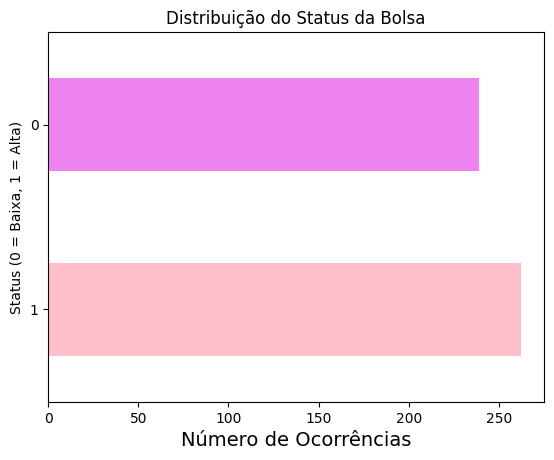

In [224]:
# Deixando mais entendivel de forma visual em um gráfico

df['Bolsa_Status'].value_counts().plot(kind='barh', color=['pink','violet'])

plt.title('Distribuição do Status da Bolsa')
plt.xlabel('Número de Ocorrências', fontsize=14)
plt.ylabel('Status (0 = Baixa, 1 = Alta)')

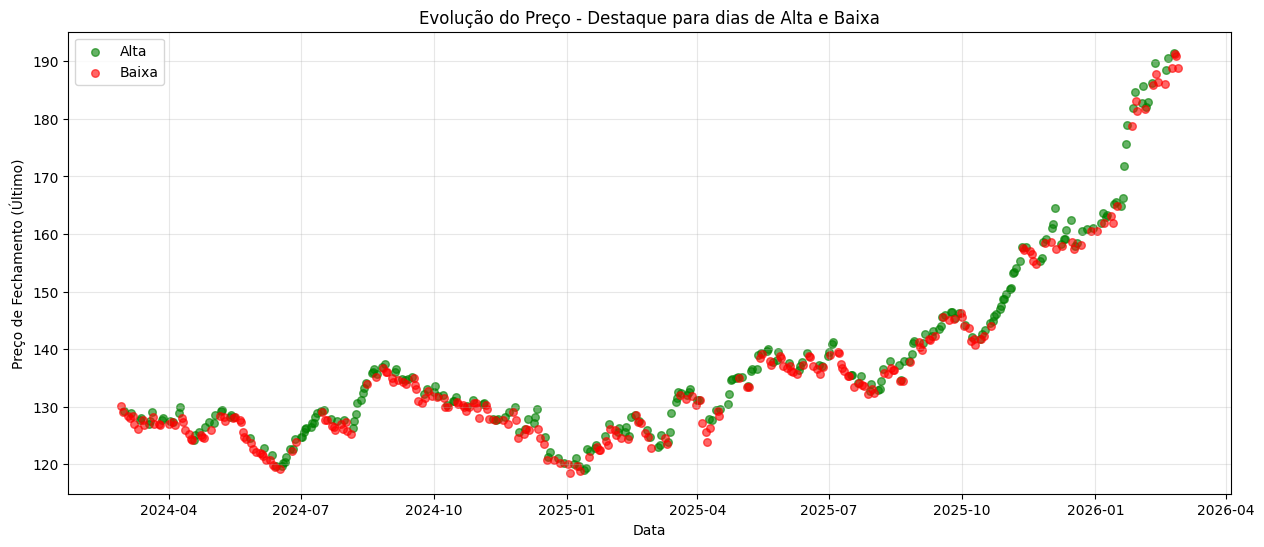

In [225]:
# Destacar dias de alta (verde) e baixa (vermelho)

plt.figure(figsize=(15,6))

plt.scatter(
  df[df['Bolsa_Status'] == 1]['Data'],
    df[df['Bolsa_Status'] == 1]['Último'],
  c='green', alpha=0.6, s=30
)

plt.scatter(
  df['Data'][df['Bolsa_Status'] == 0],  # dias de baixa
  df['Último'][df['Bolsa_Status'] == 0],  # preço de fechamento
  c='red', alpha=0.6, s=30
)

plt.title('Evolução do Preço - Destaque para dias de Alta e Baixa')
plt.xlabel('Data')
plt.ylabel('Preço de Fechamento (Último)')
plt.legend(['Alta', 'Baixa'])
plt.grid(True, alpha=0.3)
plt.show()

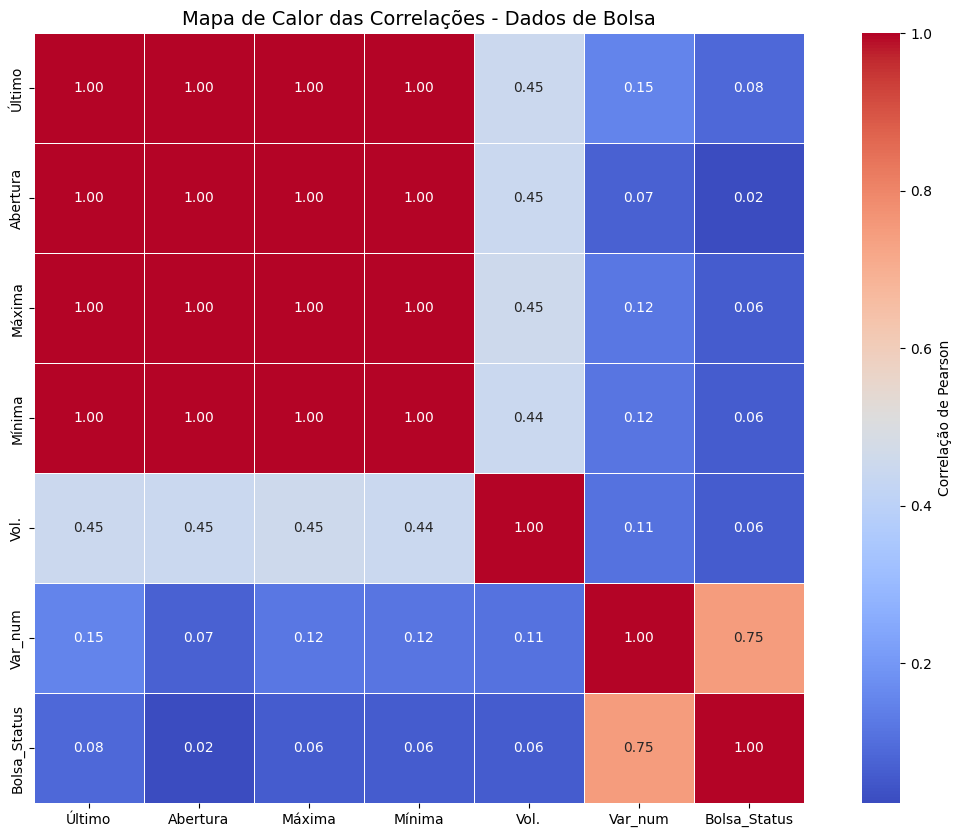

In [226]:
# Selecionar as colunas numéricas de interesse
colunas_numericas = ['Último', 'Abertura', 'Máxima', 'Mínima', 'Vol.', 'Var_num', 'Bolsa_Status']

# Calcular a matriz de correlação
corr = df[colunas_numericas].corr()

# Plotar heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(corr,
            annot=True,           # mostra os valores
            fmt='.2f',            # formato com 2 decimais
            cmap='coolwarm',       # vermelho/azul
            square=True,
            linewidths=0.5,
            cbar_kws={'label': 'Correlação de Pearson'})
plt.title('Mapa de Calor das Correlações - Dados de Bolsa', fontsize=14)
plt.show()

In [227]:
# Ordenando cronologicamente

df = df.sort_values('Data').reset_index(drop=True)

In [228]:
# Criar features defasadas (lags)

# Criar colunas defasadas (lag de 1 dia)
for col in ['Último', 'Abertura', 'Máxima', 'Mínima', 'Vol.', 'Var_num', 'Bolsa_Status']:
    df[f'{col}_lag1'] = df[col].shift(1)

# Remover linhas com NaN (primeira linha não tem lag)
df = df.dropna().reset_index(drop=True)

In [229]:
# Extraindo informações de data, mês e ano.

df['ano'] = df['Data'].dt.year
df['mes'] = df['Data'].dt.month
df['dia'] = df['Data'].dt.day
df['dia_semana'] = df['Data'].dt.dayofweek  # 0=segunda, 6=domingo

## Principais observações:
- Preços (Último, Abertura, Máxima, Mínima) têm correlação perfeita (1,00) entre si, o que é esperado pois se movem juntos.

- Volume (Vol.) tem correlação moderada (~0,45) com os preços, indicando que dias com preços mais altos tendem a ter maior volume, mas não é uma relação forte.

- Var_num (variação percentual) tem correlação baixa com os preços (0,07 a 0,15) e com volume (0,11), mostrando que a variação diária não está fortemente ligada ao nível de preço ou volume.

- Bolsa_Status (1 para alta, 0 para baixa) tem alta correlação (0,75) com Var_num, como esperado, pois é derivado dela. Com as demais variáveis, a correlação é muito baixa (0,02 a 0,08).



# Aprendizado supervisionado

No aprendizado supervisionado, lidamos com várias amostras e dados que são descritas em variaveis como features e targets.

Os dados são comumente representados em tabelas, onde existe uma linha para cada dado e uma coluna para cada feature.

Então se a varável target for algo diferente de: 1, 0, ligado, desligado; ela é uma variável target continua de atividade de regressão.

O objetivo do aprendizado supervisionado é construir um modelo que seja capaz de predizer a variável definida como target.

In [230]:
# Definindo features (x) e target (y)

features = [col for col in df.columns if 'lag1' in col] + ['ano', 'mes', 'dia', 'dia_semana']
X = df[features]
y = df['Bolsa_Status']  # target do dia atual

In [231]:
# Divisão treino/teste respeitando a ordem temporal

# Por exemplo, últimos 20% para teste
split_index = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

In [232]:
models = {"KNN": KNeighborsClassifier(),
           "Logistc Regression": LogisticRegression(max_iter=1000),
           "Random Forest": RandomForestClassifier()}

def fit_and_score(models, X_train, X_test, y_train, y_test):
  np.random.seed(42)

  model_scores = {}

  for name, model in models.items():
    model.fit(X_train, y_train)
    model_scores[name] = model.score(X_test, y_test)
  return model_scores

In [233]:
# Treinando os modelos

model_scores = fit_and_score(models=models,
                             X_train=X_train,
                             X_test=X_test,
                             y_train=y_train,
                             y_test=y_test)
model_scores

{'KNN': 0.63, 'Logistc Regression': 0.61, 'Random Forest': 0.38}

In [234]:
# Lista para armazenar o score de treino
train_scores = []

# Lista para armazenar o score de teste
test_scores = []

# Lista com diferentes valores para "n_neighbors"
# vamos começar com 1 e subir até 20
neighbors = range(1, 21)

# Instanciando o KNN
knn = KNeighborsClassifier()

# Loop para aplicar os diferentes valores em "n_neighbors"
for i in neighbors:
    knn.set_params(n_neighbors = i)
    
    # Treina o modelo
    knn.fit(X_train, y_train)
    
    # Guarda o score de treino
    train_scores.append(knn.score(X_train, y_train))
    
    # Armazena o score de teste
    test_scores.append(knn.score(X_test, y_test))


In [235]:
train_scores

[1.0,
 0.755,
 0.7625,
 0.7125,
 0.695,
 0.6925,
 0.6825,
 0.6525,
 0.6425,
 0.635,
 0.6225,
 0.6125,
 0.6175,
 0.61,
 0.5925,
 0.6125,
 0.6125,
 0.595,
 0.5825,
 0.5825]

Desempenho máximo de KNN nos dados de teste: 63.00%


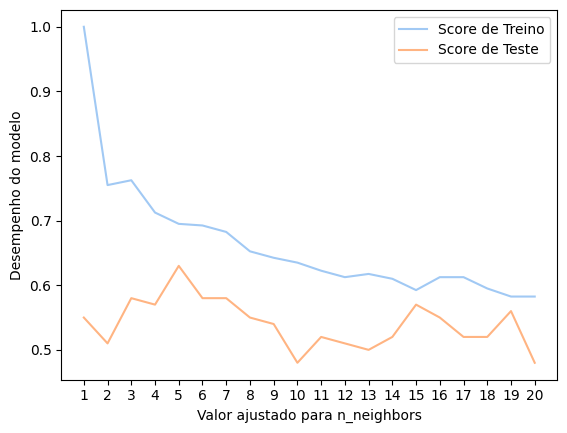

In [236]:
plt.plot(neighbors, train_scores, label="Score de Treino")
plt.plot(neighbors, test_scores, label="Score de Teste")
plt.xticks(np.arange(1, 21, 1))
plt.xlabel("Valor ajustado para n_neighbors")
plt.ylabel("Desempenho do modelo")
plt.legend()

print(f"Desempenho máximo de KNN nos dados de teste: {max(test_scores)*100:.2f}%")

In [237]:
# LogisticRegression hiperparâmetros
log_reg_grid = {"C": np.logspace(-4, 4, 20),
                "solver": ["liblinear"]}

# RandomForestClassifier hiperparâmetros
rf_grid = {"n_estimators": np.arange(10, 1000, 50),
           "max_depth": [None, 3, 5, 10],
           "min_samples_split": np.arange(2, 20, 2),
           "min_samples_leaf": np.arange(1, 20, 2)}
     

In [238]:
# Import
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

# Definindo o seed
np.random.seed(42)

# Configurando hiperparâmetros para LogisticRegression
rs_log_reg = RandomizedSearchCV(LogisticRegression(),
                                param_distributions=log_reg_grid,
                                cv=5,
                                n_iter=20,
                                verbose=True)

# Treinando o modelo com as 20 combinações possíveis
rs_log_reg.fit(X_train, y_train);

Fitting 5 folds for each of 20 candidates, totalling 100 fits


In [239]:
rs_log_reg.score(X_test, y_test)

0.61

In [240]:

rs_log_reg.best_params_

{'solver': 'liblinear', 'C': np.float64(0.0001)}

In [241]:
# Definindo o seed
np.random.seed(42)

# Configurando hiperparâmetros para RandomForestClassifier
rs_rf = RandomizedSearchCV(RandomForestClassifier(),
                           param_distributions=rf_grid,
                           cv=5,
                           n_iter=20,
                           verbose=True)

# Treinando o modelo com as 20 combinações possíveis
rs_rf.fit(X_train, y_train);

Fitting 5 folds for each of 20 candidates, totalling 100 fits


In [242]:
rs_rf.best_params_

{'n_estimators': np.int64(710),
 'min_samples_split': np.int64(12),
 'min_samples_leaf': np.int64(19),
 'max_depth': 5}

In [243]:
rs_rf.score(X_test, y_test)

0.39

In [244]:
log_reg_grid = {"C": np.logspace(-4, 4, 20),
                "solver": ["liblinear"]}

gs_log_reg = GridSearchCV(LogisticRegression(),
                          param_grid=log_reg_grid,
                          cv=5,
                          verbose=True)

gs_log_reg.fit(X_train, y_train);

Fitting 5 folds for each of 20 candidates, totalling 100 fits


In [245]:
gs_log_reg.best_params_

{'C': np.float64(0.0001), 'solver': 'liblinear'}

In [246]:
gs_log_reg.score(X_test, y_test)

0.61

In [247]:
y_preds = gs_log_reg.predict(X_test)

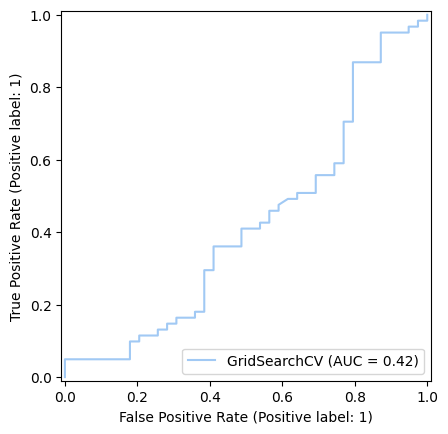

In [248]:
# Plot ROC Curve e calcula a métrica
RocCurveDisplay.from_estimator(gs_log_reg, X_test, y_test);

In [249]:

from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test, y_preds))

[[ 0 39]
 [ 0 61]]


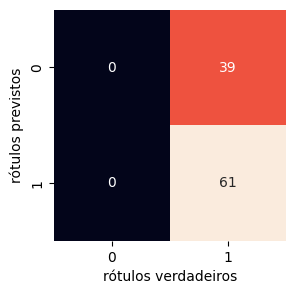

In [250]:
def plot_conf_mat(y_test, y_preds):
    fig, ax = plt.subplots(figsize=(3, 3))
    ax = sns.heatmap(confusion_matrix(y_test, y_preds),
                     annot=True,
                     cbar=False)
    plt.xlabel("rótulos verdadeiros")
    plt.ylabel("rótulos previstos")
    
plot_conf_mat(y_test, y_preds)

In [251]:
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        39
           1       0.61      1.00      0.76        61

    accuracy                           0.61       100
   macro avg       0.30      0.50      0.38       100
weighted avg       0.37      0.61      0.46       100



In [252]:
gs_log_reg.best_params_

{'C': np.float64(0.0001), 'solver': 'liblinear'}

In [253]:
# Importa cross_val_score
from sklearn.model_selection import cross_val_score

# Passando o melhor modelo com os melhores hiperparâmetros
# que encontramos com (GridSearchCV)
clf = LogisticRegression(C=0.23357214690901212,
                         solver="liblinear")

In [254]:
# Cross-validated (validação cruzada)
cv_acc = cross_val_score(clf,
                         X,
                         y,
                         cv=5, # 5-fold
                         scoring="accuracy")
cv_acc

array([0.52, 0.52, 0.52, 0.53, 0.53])

In [255]:
cv_acc = np.mean(cv_acc)
cv_acc
     

np.float64(0.524)

In [256]:
cv_precision = np.mean(cross_val_score(clf,
                                       X,
                                       y,
                                       cv=5,
                                       scoring="precision"))

cv_recall = np.mean(cross_val_score(clf,
                                    X,
                                    y,
                                    cv=5,
                                    scoring="recall"))

cv_f1 = np.mean(cross_val_score(clf,
                                X,
                                y,
                                cv=5,
                                scoring="f1"))

cv_precision, cv_recall, cv_f1

(np.float64(0.524), np.float64(1.0), np.float64(0.6876504987960097))

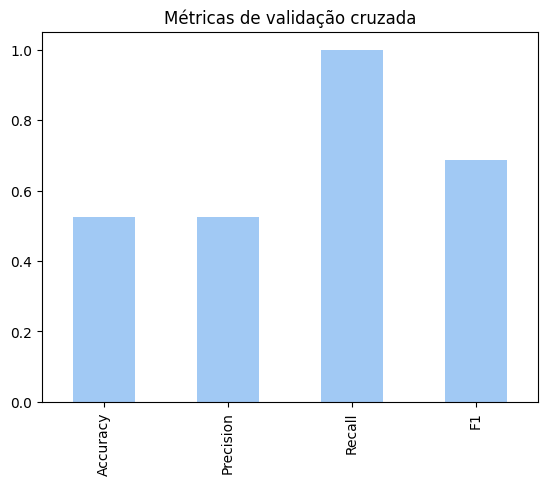

In [257]:
# Plot cross-validated metrics
cv_metrics = pd.DataFrame({"Accuracy": cv_acc,
                            "Precision": cv_precision,
                            "Recall": cv_recall,
                            "F1": cv_f1},
                            index=[0])
cv_metrics.T.plot.bar(title="Métricas de validação cruzada", legend=False);

In [258]:
clf.fit(X_train, y_train);
clf.coef_

array([[-1.23432037e-19, -1.21964577e-19, -1.23322335e-19,
        -1.22212408e-19,  1.11327686e-11, -1.33162792e-21,
        -2.13914228e-21, -1.30926156e-18, -5.55976444e-21,
        -4.63760429e-20, -1.24822668e-20]])

In [259]:
features_dict = dict(zip(df.columns, list(clf.coef_[0])))
features_dict

{'Data': np.float64(-1.2343203747059932e-19),
 'Último': np.float64(-1.2196457676161586e-19),
 'Abertura': np.float64(-1.2332233505032732e-19),
 'Máxima': np.float64(-1.2221240783611906e-19),
 'Mínima': np.float64(1.1132768630199259e-11),
 'Vol.': np.float64(-1.331627923306693e-21),
 'Var%': np.float64(-2.1391422767906207e-21),
 'Var_num': np.float64(-1.3092615563641623e-18),
 'Bolsa_Status': np.float64(-5.559764440294103e-21),
 'Último_lag1': np.float64(-4.6376042941687195e-20),
 'Abertura_lag1': np.float64(-1.2482266765312713e-20)}

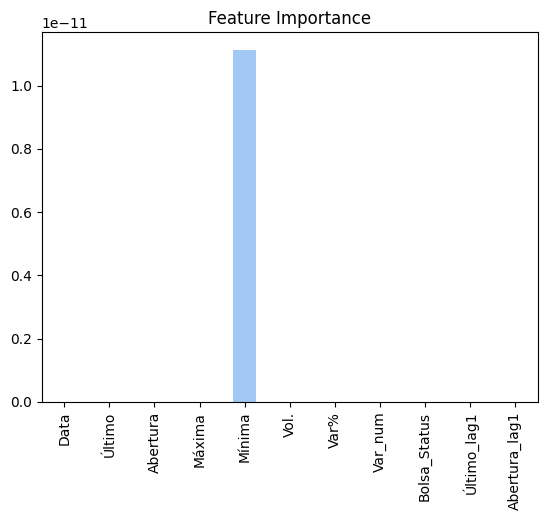

In [260]:

features_df = pd.DataFrame(features_dict, index=[0])
features_df.T.plot.bar(title="Feature Importance", legend=False);